# Single-qubit calibration (co-simulation)

The co-sim analogue of the hardware `Calibration_X6Y3` notebook. Instead of a real qubit we
drive the Verilated `PulseTableSoc` against a `TwoLevelModel` with **planted ground truth**
(`f_ge`, Rabi rate, T1, T2), start from a **deliberately-detuned `Config`**, and run the
`Calibration_X6Y3` flow one experiment per cell:

> ReadoutCalibration → Separation → Fidelity → ReadoutFidelity → Frequency →
> Amplitude (coarse) → Amplitude (fine) → Phase

Each cell is `r = Cal(...).run(drv); r.apply()`; we watch the `Config` move toward the
planted truth. The notebook owns the sim lifecycle (`server.start` … `server.stop`).

In [1]:
import math
from pathlib import Path

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import riscq
from riscq.cal import (Config, ReadoutCalibration, Separation, Fidelity, ReadoutFidelity,
                       Frequency, Amplitude, Phase)
from riscq.cal.base import bind_params, gate_sigma, GATE_ENV
from riscq.map import SocMap, SocParams
from riscq.pulses import Pulse, units
from riscq.sim import server

SW = Path(riscq.__file__).resolve().parents[1]   # .../software (robust to the notebook cwd)
F_GE = 50e6                                       # planted qubit frequency

## Bring up the co-sim and derive the SocMap

In [2]:
drv = server.start(SW / 'configs' / 'sim-2q.json', SW / 'build' / 'sim-2q')
m = SocMap(SocParams.from_json(drv.sim.get_params()))
bind_params(m)                                   # give the pulse-unit helpers the build params
print('cosim up; qubits =', m.params.qubit_num)

cosim up; qubits = 2


## Plant the ground truth

A `TwoLevelModel` on core 0 with a Rabi rate set to ~1.5 Rabi periods across a full-scale
amplitude sweep, plus T1/T2 and a little readout shot noise. We record the *true* X90
amplitude (the amplitude that rotates by exactly π/2) so we can score the calibration.

In [3]:
x90_full = Pulse(GATE_ENV, freq_hz=F_GE, amp=0.5)
sig_max = gate_sigma(m, x90_full, F_GE, units.AMP_SCALE - 600)   # drive integral at full scale
rabi = float(3 * math.pi / sig_max)                             # ~1.5 Rabi periods over the sweep

drv.sim.set_model(dict(kind='twolevel', core=0, rabi_rad_per_amp=rabi, readout_code=2048,
                       readout_amp=20000.0, readout_phase=0.0, f_ge=F_GE,
                       t1=300, t2=450, noise_scale=150.0, noise_seed=0))

g = sig_max / (units.AMP_SCALE - 600)                          # drive per amp code (linear)
true_x90_amp = (math.pi / 2) / (rabi * g) / units.AMP_SCALE     # amp that gives a π/2 rotation
print(f'planted rabi={rabi:.3e} rad/amp   true X90 amp≈{true_x90_amp:.4f}')

planted rabi=7.416e-05 rad/amp   true X90 amp≈0.1616


## A deliberately-detuned starting Config

The drive carrier is off `f_ge` by `d0_code` codes and the X90 amplitude is wrong (0.5 vs
the true ≈0.16). The calibrations must pull both back.

In [4]:
d0_code = 60
drive = units.code_to_freq(units.freq_to_code(F_GE, m.params) + d0_code, m.params)

cfg = Config()
cfg['qubit/0/freq'] = float(drive)
cfg['qubit/0/x90/amp'] = 0.5
cfg['qubit/0/T1'] = 120
cfg['readout/0/freq'] = float(units.demod_code_to_freq(2048, m.params))
cfg['readout/0/dur'] = 40

freq_err0 = abs(cfg['qubit/0/freq'] - F_GE)
amp_err0 = abs(cfg['qubit/0/x90/amp'] - true_x90_amp)
print(f'start: freq err={freq_err0:.3g} Hz   X90 amp err={amp_err0:.4f}')

def apply_if_ok(r):
    '''Print the step, apply its proposal only if the fit succeeded (a failed fit refuses).'''
    print(f'{r.label}: ok={r.ok}  proposal={r.proposal}')
    if r.ok:
        r.apply()
    else:
        print('  fit failed — Config left unchanged')
    return r

start: freq err=1.46e+06 Hz   X90 amp err=0.3384


## Readout calibration

Train the |0⟩/|1⟩ IQ classifier, then find the readout (demod) frequency, the best
integration window, and the assignment-fidelity confusion matrix.

ReadoutCalibration q0: ok=True  proposal={'readout/0/demod_phase': 2.344026858756915, 'readout/0/res_sign': 1}


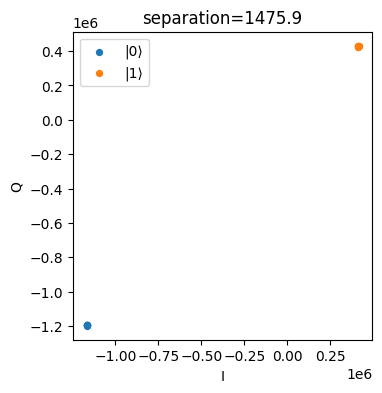

In [5]:
rc = apply_if_ok(ReadoutCalibration(cfg, 0, shots=8).run(drv))
iq0, iq1 = rc.data['iq0'], rc.data['iq1']
plt.figure(figsize=(4, 4))
plt.scatter(iq0[:, 0], iq0[:, 1], label='|0⟩', s=18)
plt.scatter(iq1[:, 0], iq1[:, 1], label='|1⟩', s=18)
plt.gca().set_aspect('equal'); plt.legend(); plt.title(f"separation={rc.data['separation']:.1f}")
plt.xlabel('I'); plt.ylabel('Q'); plt.show()

Separation q0: ok=True  proposal={'readout/0/freq': 12500000.0}


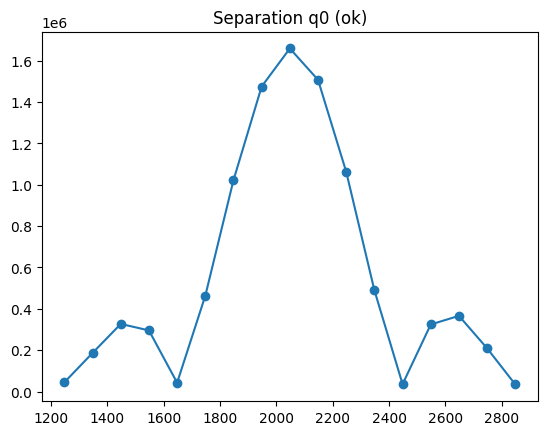

readout/0/freq -> 1.25e+07 Hz


In [6]:
sep = apply_if_ok(Separation(cfg, 0, points=17).run(drv))
sep.plot(); plt.show()
print(f"readout/0/freq -> {cfg['readout/0/freq']:.4g} Hz")

In [7]:
fid = apply_if_ok(Fidelity(cfg, 0, durs=(24, 48), shots=5).run(drv))
rf = apply_if_ok(ReadoutFidelity(cfg, 0, shots=8).run(drv))
print('readout window ->', cfg['readout/0/dur'], 'batches')
print('confusion matrix (row=prepared, col=classified):')
print(np.round(rf.data['confusion'], 3), ' fidelity=', round(rf.data['fidelity'], 3))

Fidelity q0: ok=True  proposal={'readout/0/dur': 48}


ReadoutFidelity q0: ok=True  proposal={'readout/0/fidelity': 1.0}
readout window -> 48 batches
confusion matrix (row=prepared, col=classified):
[[1. 0.]
 [0. 1.]]  fidelity= 1.0


## Qubit calibration

Ramsey-vs-detuning recovers the drive frequency; a coarse then fine (repeated-pulse)
Amplitude sweep sets the X90 amplitude; Phase checks the X90 axis error.

In [8]:
fr = apply_if_ok(Frequency(cfg, 0, detune_code=200, n_detune=4, points=14, dt=4).run(drv))
print(f'recovered detuning code ≈ {fr.data["obs"]}  (planted d0_code={d0_code})')
print(f"qubit/0/freq err: {freq_err0:.3g} -> {abs(cfg['qubit/0/freq'] - F_GE):.3g} Hz")

/config/build/agentic-rv-dev/software/riscq/cal/fits.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=p0, maxfev=20000)


Frequency q0: ok=True  proposal={'qubit/0/freq': 50000000.0}
recovered detuning code ≈ [ 259.86414403 -340.31726864  459.70963783]  (planted d0_code=60)
qubit/0/freq err: 1.46e+06 -> 0 Hz


Amplitude q0 n_gates=1: ok=True  proposal={'qubit/0/x90/amp': 0.16150234896503676, 'qubit/0/rabi': 7.422550078859869e-05}


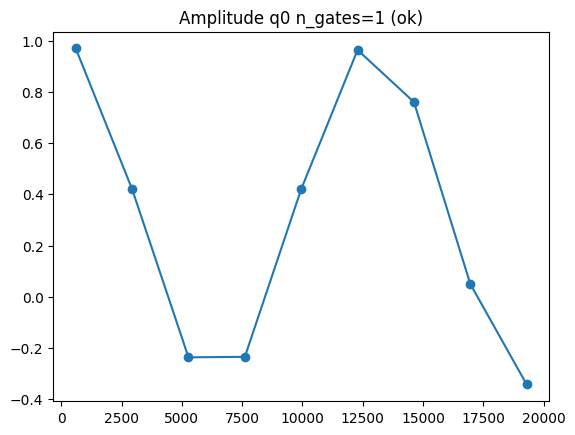

coarse X90 amp -> 0.1615  (true≈0.1616)


In [9]:
ac = apply_if_ok(Amplitude(cfg, 0, n_gates=1, points=9).run(drv))   # coarse Rabi (cosine)
ac.plot(); plt.show()
print(f"coarse X90 amp -> {cfg['qubit/0/x90/amp']:.4f}  (true≈{true_x90_amp:.4f})")

In [10]:
cur = int(round(float(cfg['qubit/0/x90/amp']) * units.AMP_SCALE))
fine = list(np.linspace(max(400, int(0.8 * cur)), int(1.2 * cur), 9).astype(int))
af = apply_if_ok(Amplitude(cfg, 0, n_gates=4, amp_codes=fine).run(drv))   # fine (repeated-pulse)
print(f"fine X90 amp -> {cfg['qubit/0/x90/amp']:.4f}  (true≈{true_x90_amp:.4f})")

Amplitude q0 n_gates=4: ok=True  proposal={'qubit/0/x90/amp': 0.1618161334425455}
fine X90 amp -> 0.1618  (true≈0.1616)


In [11]:
ph = apply_if_ok(Phase(cfg, 0, points=7).run(drv))
print(f"X90 axis phase -> {cfg.get('qubit/0/x90/phase', 0.0):+.4f} rad (planted 0)")

Phase q0: ok=True  proposal={'qubit/0/x90/phase': 1.57458241482139}
X90 axis phase -> +1.5746 rad (planted 0)


## Summary — the Config converged toward the planted truth

In [12]:
freq_err1 = abs(cfg['qubit/0/freq'] - F_GE)
amp_err1 = abs(cfg['qubit/0/x90/amp'] - true_x90_amp)
print(f'qubit freq  err: {freq_err0:10.3g} -> {freq_err1:10.3g} Hz')
print(f'X90 amp     err: {amp_err0:10.4f} -> {amp_err1:10.4f}')
print(f'X90 amp: {cfg["qubit/0/x90/amp"]:.4f}  (planted true ≈ {true_x90_amp:.4f})')
assert freq_err1 < freq_err0 and amp_err1 < amp_err0, 'calibration did not improve the Config'
print('\nOK — both the frequency and the X90 amplitude improved.')

qubit freq  err:   1.46e+06 ->          0 Hz
X90 amp     err:     0.3384 ->     0.0002
X90 amp: 0.1618  (planted true ≈ 0.1616)

OK — both the frequency and the X90 amplitude improved.


## Tear down the co-sim

In [13]:
drv.sim.set_model({'kind': 'zero'})
server.stop(drv)
print('cosim stopped')

cosim stopped
